# Mid-term Project: Bank Term Deposit Prediction

## Problem Statement

As a Data Scientist at a bank, the goal is to build a classification model to predict whether a client will subscribe to a term deposit based on marketing campaign data.

## Dataset

The data comes from direct marketing campaigns (phone calls) of a Portuguese banking institution. The target variable `y` indicates whether the client subscribed to a term deposit.

**Source**: [Kaggle - Bank Additional Full CSV](https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv)

## Project Plan

1. Exploratory Data Analysis (EDA) + hypotheses
2. Metric selection with justification
3. Data preprocessing (encoding, grouping, outliers, feature engineering)
4. Train 4 models: Logistic Regression, kNN, Decision Tree, XGBoost
5. Model comparison table
6. Hyperparameter tuning: RandomizedSearch + Hyperopt
7. Feature importance analysis
8. SHAP analysis
9. Error analysis + improvement suggestions

In [1]:
# 1. Import Libraries & Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from xgboost import XGBClassifier
import shap

pd.set_option('display.max_columns', 25)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Mount Google Drive and load data
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("drive/MyDrive/Machine Learning для людей/data/mid-term/bank-additional-full.csv", sep=';')
print(f"Dataset shape: {df.shape}")
df.head()

Mounted at /content/drive
Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
# General dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [3]:
# Descriptive statistics — numeric features
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [4]:
# Descriptive statistics — categorical features
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Variable Distribution

We first check the class balance of the target variable `y`. This is critical for metric selection and modeling strategy.

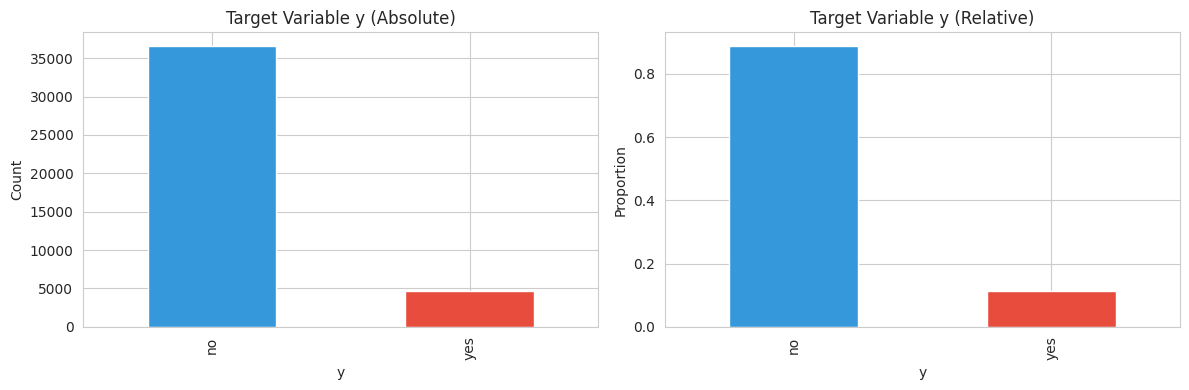


Class distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Positive class (yes) ratio: 11.27%


In [5]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['y'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Target Variable y (Absolute)')
axes[0].set_xlabel('y')
axes[0].set_ylabel('Count')

df['y'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'])
axes[1].set_title('Target Variable y (Relative)')
axes[1].set_xlabel('y')
axes[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

print(f"\nClass distribution:\n{df['y'].value_counts()}")
print(f"\nPositive class (yes) ratio: {df['y'].value_counts(normalize=True)['yes']:.2%}")

### 2.2 Numeric Features Analysis

Numeric features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


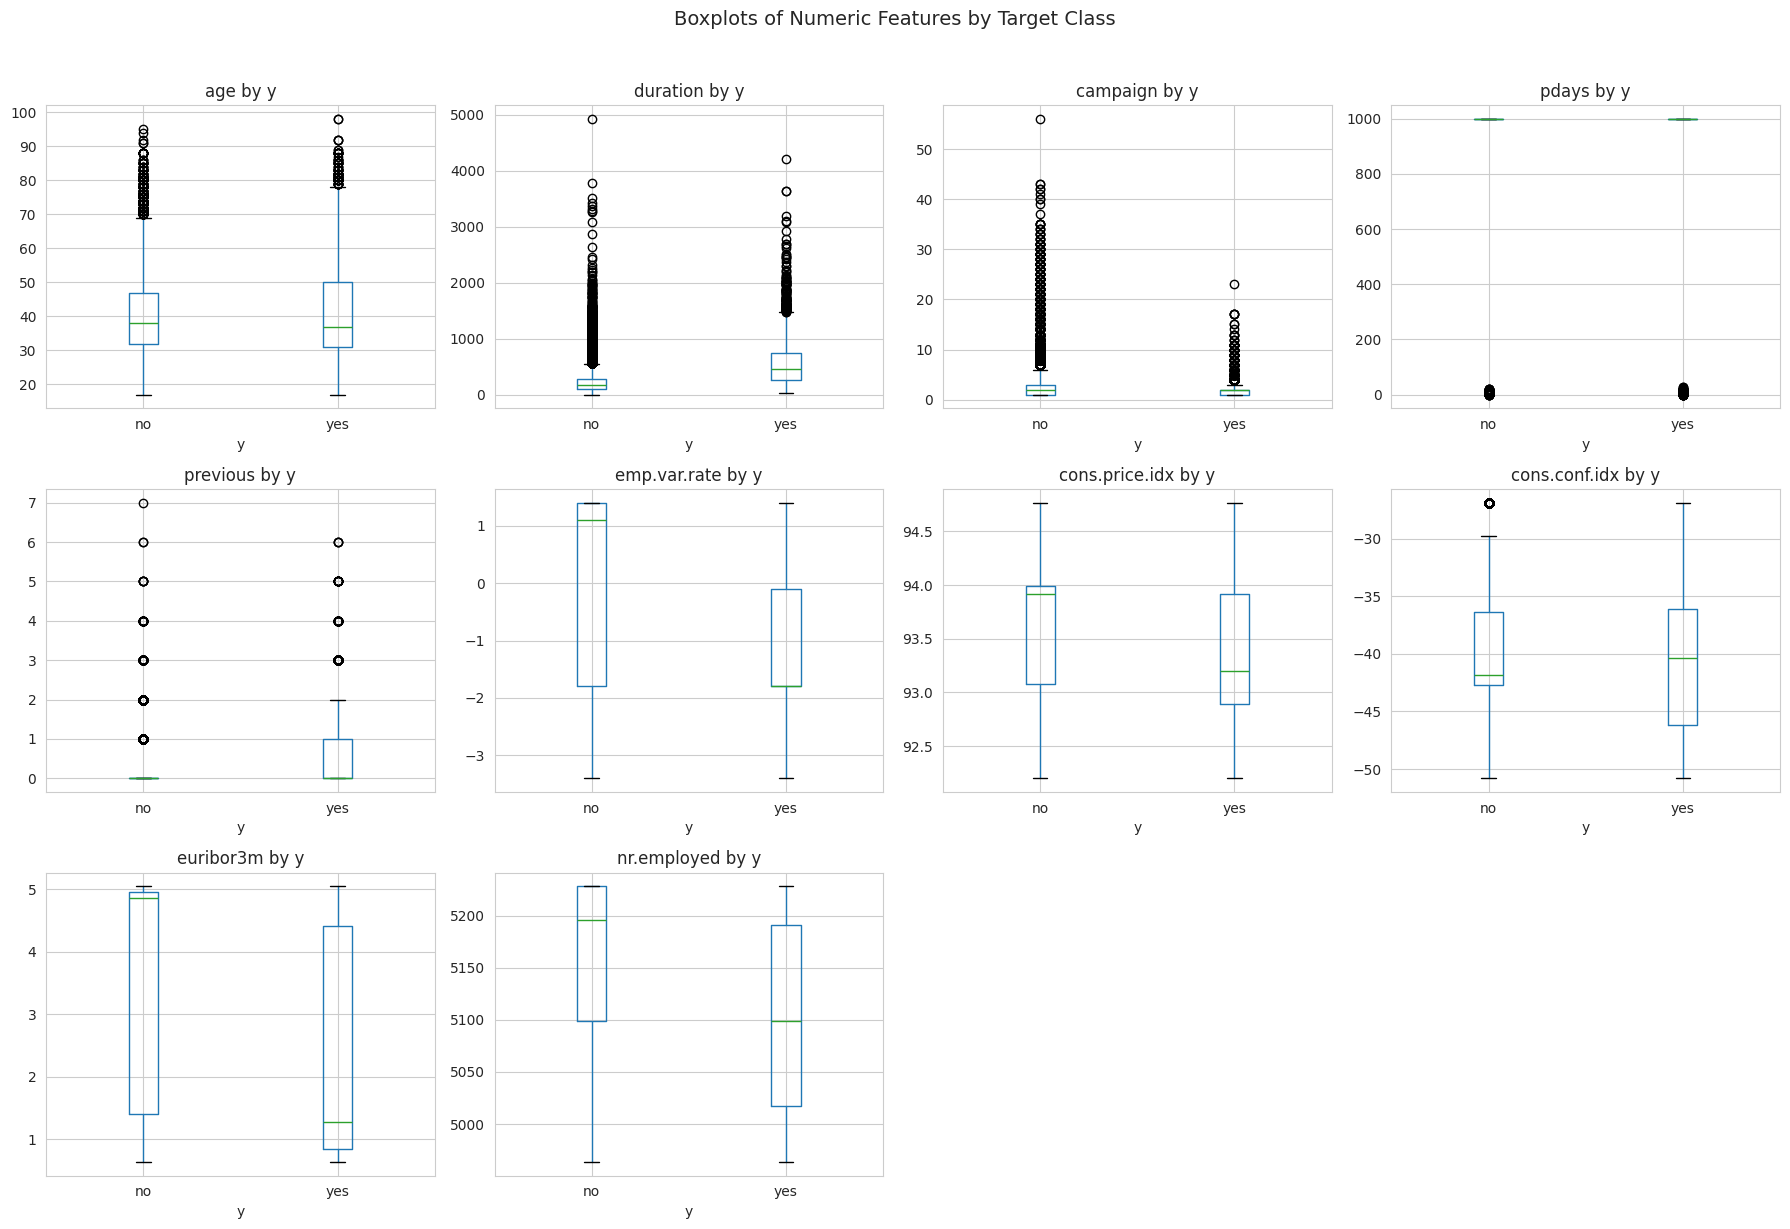

In [6]:
# Boxplots of numeric features by target class
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features: {numeric_cols}")

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='y', ax=axes[i])
    axes[i].set_title(f'{col} by y')
    axes[i].set_xlabel('y')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numeric Features by Target Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

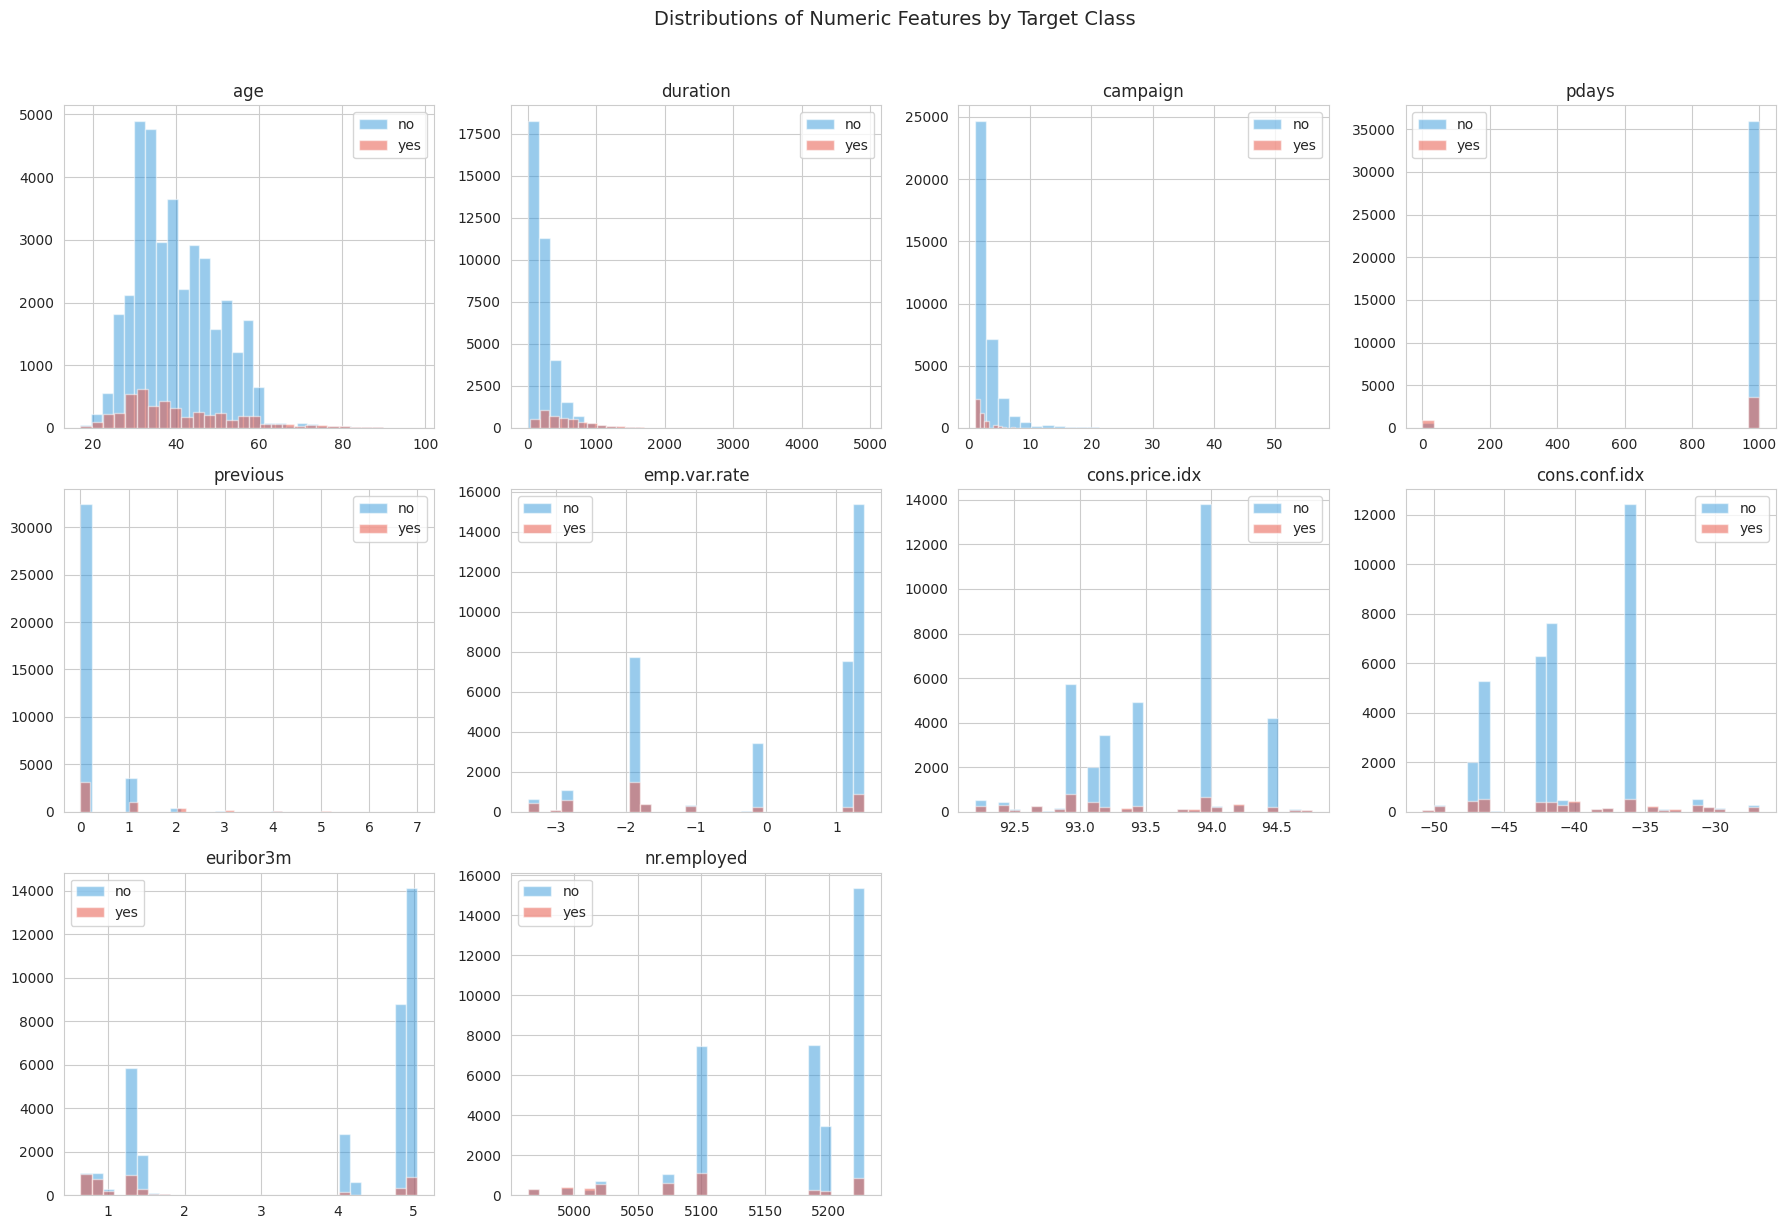

In [7]:
# Histograms of numeric features by target class
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in zip(['no', 'yes'], ['#3498db', '#e74c3c']):
        axes[i].hist(df[df['y'] == label][col], bins=30, alpha=0.5, label=label, color=color)
    axes[i].set_title(col)
    axes[i].legend()

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions of Numeric Features by Target Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

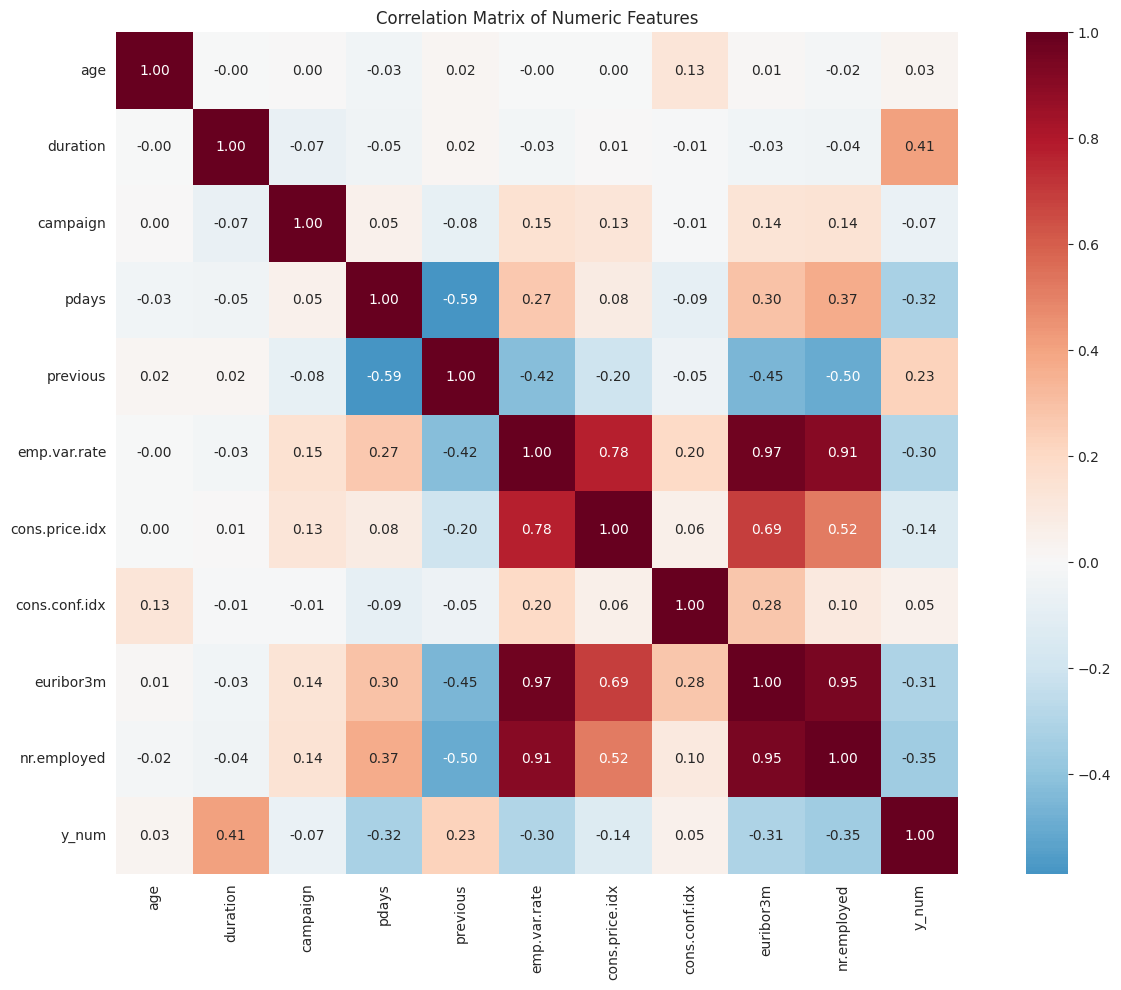

In [8]:
# Correlation matrix
plt.figure(figsize=(14, 10))
df_corr = df.copy()
df_corr['y_num'] = (df_corr['y'] == 'yes').astype(int)
corr_matrix = df_corr[numeric_cols + ['y_num']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

### 2.3 Categorical Features Analysis

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


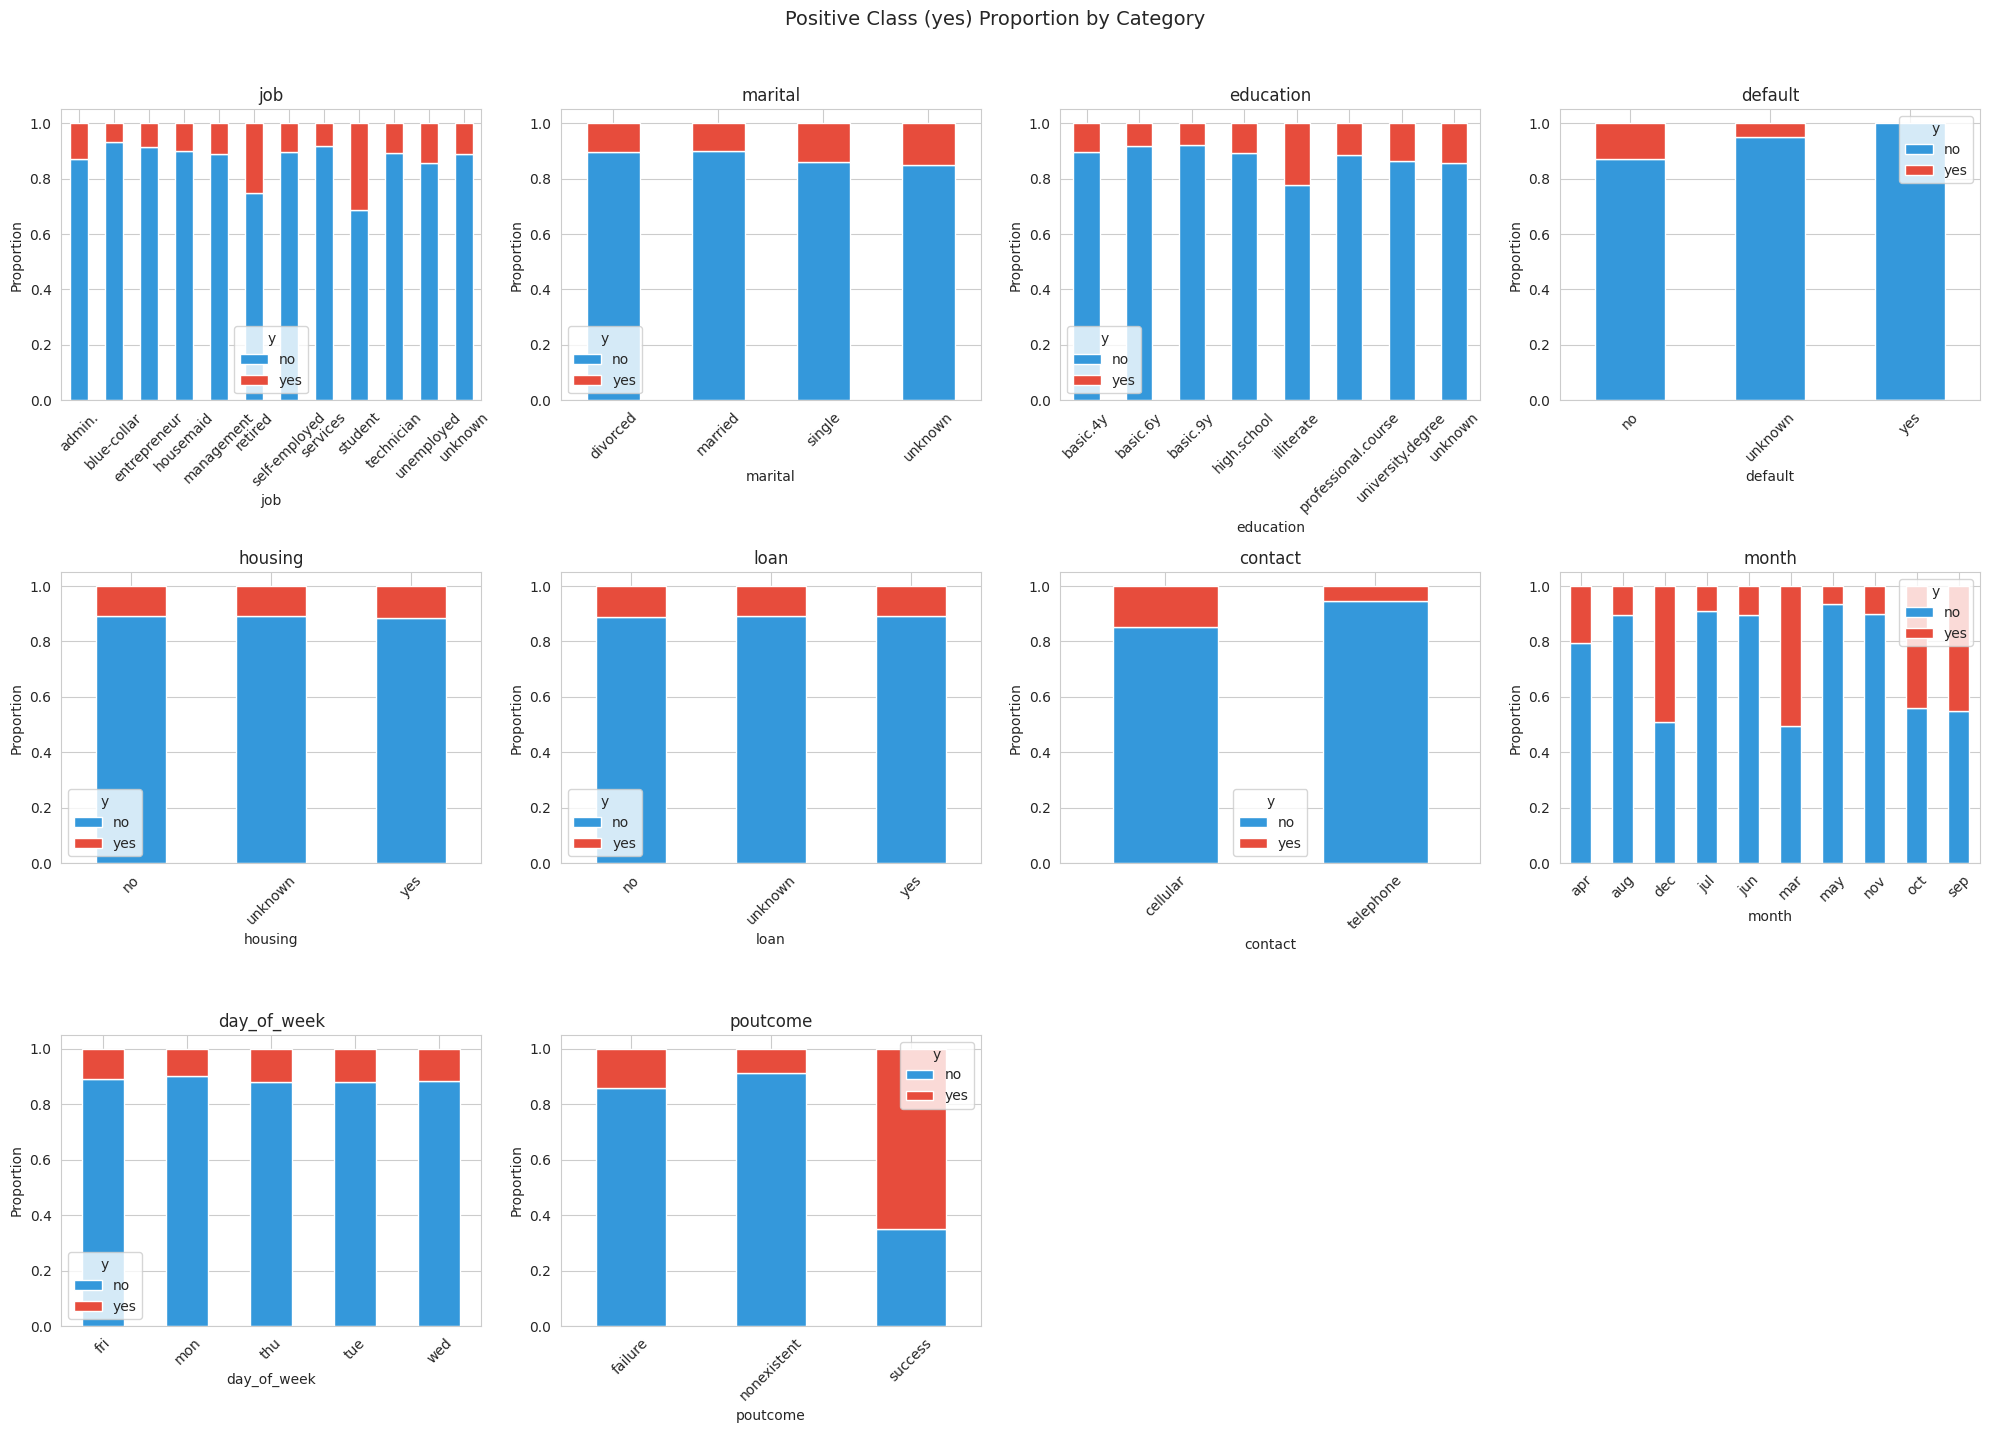

In [9]:
# Categorical features and their relationship with the target
cat_cols = df.select_dtypes(include='object').columns.drop('y').tolist()
print(f"Categorical features: {cat_cols}")

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['y'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#3498db', '#e74c3c'])
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Proportion')
    axes[i].legend(title='y')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Positive Class (yes) Proportion by Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Check for missing values and "unknown" entries
print("Missing values (NaN):")
print(df.isnull().sum())
print(f"\nTotal NaN count: {df.isnull().sum().sum()}")

print("\n\n'unknown' values in categorical features:")
for col in cat_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"  {col}: {unknown_count} ({unknown_count/len(df):.2%})")

Missing values (NaN):
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Total NaN count: 0


'unknown' values in categorical features:
  job: 330 (0.80%)
  marital: 80 (0.19%)
  education: 1731 (4.20%)
  default: 8597 (20.87%)
  housing: 990 (2.40%)
  loan: 990 (2.40%)


### 2.4 Hypotheses Based on EDA

Based on the exploratory analysis, we formulate the following hypotheses:

1. **Call duration (`duration`)** is the strongest predictor: the longer the call, the higher the chance of subscription. However, this feature **cannot be used** in the final model since it's unknown before the call is made.

2. **Macroeconomic indicators** (`euribor3m`, `emp.var.rate`, `nr.employed`) have a strong negative correlation with `y`: during economic downturns (lower rates, fewer employed), clients are more likely to open deposits as a safe investment.

3. **Previous campaign outcome (`poutcome`)**: clients who previously subscribed (`success`) have a significantly higher probability of subscribing again.

4. **Age (`age`)**: students and retirees have a higher conversion rate than working-age adults.

5. **Contact type (`contact`)**: cellular contact yields better results than landline telephone.

6. **Number of contacts (`campaign`)**: excessive calls (>5) do not improve conversion — they may even decrease it.

7. **Seasonality (`month`)**: March, September, October, and December show higher conversion rates.

---

## 3. Metric Selection

**Chosen metrics: F1-score and ROC-AUC**

Justification:
- The dataset is **highly imbalanced** (~11% positive class). Accuracy would be misleadingly high (a model that always predicts "no" would achieve ~89% accuracy).
- **F1-score** balances precision and recall, which is important: we want to correctly identify potential subscribers (recall) without wasting resources on false positives (precision).
- **ROC-AUC** provides an overall picture of the model's ability to discriminate between classes, independent of the classification threshold.
- We use **F1-score** as the primary metric for model comparison and **ROC-AUC** as a supplementary metric.

## 4. Data Preprocessing

### 4.1 Remove `duration` Feature

As stated in the dataset description, `duration` is unknown before the call is made, so it cannot be used in a real predictive model.

In [11]:
df_model = df.copy()
df_model = df_model.drop('duration', axis=1)

# Encode target variable
df_model['y'] = (df_model['y'] == 'yes').astype(int)
print(f"Target variable distribution after encoding:\n{df_model['y'].value_counts()}")

Target variable distribution after encoding:
y
0    36548
1     4640
Name: count, dtype: int64


### 4.2 Categorical Variable Processing & Feature Engineering

- Group education levels `basic.4y`, `basic.6y`, `basic.9y` into `basic` (all represent basic education)
- Create binary feature `was_contacted_before` based on `pdays` (whether the client was contacted in a previous campaign)
- For `pdays`: value 999 means no previous contact — replace with -1 for better interpretability

In [12]:
# Group education levels
df_model['education'] = df_model['education'].replace({
    'basic.4y': 'basic',
    'basic.6y': 'basic',
    'basic.9y': 'basic'
})
print("Education levels after grouping:", df_model['education'].unique())

# Create new features
df_model['was_contacted_before'] = (df_model['pdays'] != 999).astype(int)
df_model['pdays_clean'] = df_model['pdays'].replace(999, -1)

print(f"\nCampaign stats: min={df_model['campaign'].min()}, max={df_model['campaign'].max()}, "
      f"median={df_model['campaign'].median()}, mean={df_model['campaign'].mean():.1f}")

print(f"\nNew features created: was_contacted_before, pdays_clean")

Education levels after grouping: ['basic' 'high.school' 'professional.course' 'unknown' 'university.degree'
 'illiterate']

Campaign stats: min=1, max=56, median=2.0, mean=2.6

New features created: was_contacted_before, pdays_clean


### 4.3 Outlier Detection and Handling

We check numeric variables for outliers using the IQR method. For variables with naturally large ranges (macroeconomic indicators), we leave outliers as-is.

In [13]:
# Outlier analysis using IQR method
check_cols = ['age', 'campaign', 'previous']

for col in check_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_model[(df_model[col] < lower) | (df_model[col] > upper)]
    print(f"{col}: IQR=[{Q1}, {Q3}], bounds=[{lower:.1f}, {upper:.1f}], "
          f"outliers: {len(outliers)} ({len(outliers)/len(df_model):.2%})")

# Decision: cap campaign at 99th percentile (winsorize), do not remove rows
cap_value = df_model['campaign'].quantile(0.99)
print(f"\nCapping campaign at 99th percentile: {cap_value}")
df_model['campaign'] = df_model['campaign'].clip(upper=cap_value)

# For age: keep as-is — age outliers have business significance (retirees/students)
print("Age outliers are kept — retirees and young clients have meaningful business value.")

age: IQR=[32.0, 47.0], bounds=[9.5, 69.5], outliers: 469 (1.14%)
campaign: IQR=[1.0, 3.0], bounds=[-2.0, 6.0], outliers: 2406 (5.84%)
previous: IQR=[0.0, 0.0], bounds=[0.0, 0.0], outliers: 5625 (13.66%)

Capping campaign at 99th percentile: 14.0
Age outliers are kept — retirees and young clients have meaningful business value.


### 4.4 Encoding Categorical Variables & Preparing Data for Modeling

In [14]:
# Drop original pdays (we use pdays_clean instead)
df_model = df_model.drop('pdays', axis=1)

# Identify categorical and numeric features
cat_features = df_model.select_dtypes(include='object').columns.tolist()
num_features = df_model.select_dtypes(include=[np.number]).columns.drop('y').tolist()

print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"Numeric features ({len(num_features)}): {num_features}")

# One-Hot Encoding for categorical variables
df_encoded = pd.get_dummies(df_model, columns=cat_features, drop_first=True)

print(f"\nDataset shape after OHE: {df_encoded.shape}")
df_encoded.head()

Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric features (10): ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before', 'pdays_clean']

Dataset shape after OHE: (41188, 52)


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_contacted_before,pdays_clean,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,-1,False,...,False,False,True,False,False,False,True,False,False,False,True,False
1,57,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,-1,False,...,False,False,True,False,False,False,True,False,False,False,True,False
2,37,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,-1,False,...,False,False,True,False,False,False,True,False,False,False,True,False
3,40,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,-1,False,...,False,False,True,False,False,False,True,False,False,False,True,False
4,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,-1,False,...,False,False,True,False,False,False,True,False,False,False,True,False


In [15]:
# Train/test split
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, positive class: {y_train.mean():.2%}")
print(f"Test set: {X_test.shape}, positive class: {y_test.mean():.2%}")

# Scale numeric features (required for LogReg and kNN)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

print(f"\nData is ready for modeling.")

Training set: (32950, 51), positive class: 11.27%
Test set: (8238, 51), positive class: 11.26%

Data is ready for modeling.


## 5. Modeling

### 5.1 Model Descriptions

1. **Logistic Regression** — linear model, highly interpretable, serves as a baseline. Requires scaled features. We use `class_weight='balanced'` to handle class imbalance.

2. **kNN (k-Nearest Neighbors)** — non-parametric model, sensitive to feature scaling. We select the optimal k via cross-validation.

3. **Decision Tree** — tree-based model, easy to interpret and visualize. Prone to overfitting without depth constraints.

4. **XGBoost** — gradient boosting algorithm, one of the most effective for tabular data. Has built-in mechanisms for handling class imbalance (`scale_pos_weight`).

### 5.2 Training Models

In [16]:
# Helper function for model evaluation
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    """Train model and return metrics"""
    model.fit(X_tr, y_tr)

    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)

    y_train_proba = model.predict_proba(X_tr)[:, 1] if hasattr(model, 'predict_proba') else None
    y_test_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    f1_train = f1_score(y_tr, y_train_pred)
    f1_test = f1_score(y_te, y_test_pred)

    roc_train = roc_auc_score(y_tr, y_train_proba) if y_train_proba is not None else None
    roc_test = roc_auc_score(y_te, y_test_proba) if y_test_proba is not None else None

    print(f"=== {model_name} ===")
    print(f"F1 (train): {f1_train:.4f} | F1 (test): {f1_test:.4f}")
    if roc_test:
        print(f"ROC-AUC (train): {roc_train:.4f} | ROC-AUC (test): {roc_test:.4f}")
    print(f"\nClassification Report (test):")
    print(classification_report(y_te, y_test_pred))
    print("-" * 60)

    return {
        'model_name': model_name,
        'f1_train': f1_train,
        'f1_test': f1_test,
        'roc_auc_train': roc_train,
        'roc_auc_test': roc_test,
        'model': model
    }

results = []

# Compute class weights for XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost: {scale_pos:.2f}")

scale_pos_weight for XGBoost: 7.88


In [17]:
# 1. Logistic Regression (uses scaled data)
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=1.0
)
res_lr = evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic Regression')
res_lr['hyperparams'] = "C=1.0, class_weight='balanced', max_iter=1000"
results.append(res_lr)

=== Logistic Regression ===
F1 (train): 0.4521 | F1 (test): 0.4695
ROC-AUC (train): 0.7946 | ROC-AUC (test): 0.8013

Classification Report (test):
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.84      0.85      8238

------------------------------------------------------------


Best k: 5 (F1 CV: 0.3654)


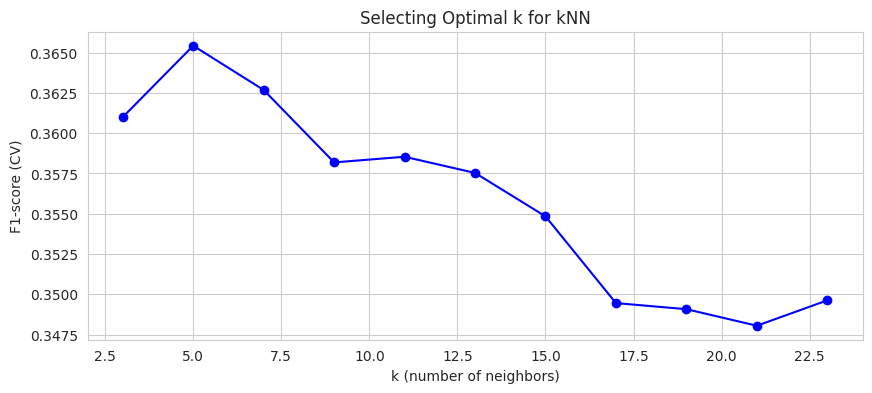

=== kNN ===
F1 (train): 0.4996 | F1 (test): 0.3792
ROC-AUC (train): 0.9254 | ROC-AUC (test): 0.7420

Classification Report (test):
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.56      0.29      0.38       928

    accuracy                           0.89      8238
   macro avg       0.74      0.63      0.66      8238
weighted avg       0.87      0.89      0.88      8238

------------------------------------------------------------


In [18]:
# 2. kNN (uses scaled data)
# Select optimal k via cross-validation
k_values = range(3, 25, 2)
cv_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=5, scoring='f1')
    cv_scores.append(scores.mean())

best_k = list(k_values)[np.argmax(cv_scores)]
print(f"Best k: {best_k} (F1 CV: {max(cv_scores):.4f})")

plt.figure(figsize=(10, 4))
plt.plot(k_values, cv_scores, 'bo-')
plt.xlabel('k (number of neighbors)')
plt.ylabel('F1-score (CV)')
plt.title('Selecting Optimal k for kNN')
plt.grid(True)
plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
res_knn = evaluate_model(knn, X_train_scaled, X_test_scaled, y_train, y_test, 'kNN')
res_knn['hyperparams'] = f"n_neighbors={best_k}"
results.append(res_knn)

In [19]:
# 3. Decision Tree (does not require scaling)
dt = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
res_dt = evaluate_model(dt, X_train, X_test, y_train, y_test, 'Decision Tree')
res_dt['hyperparams'] = "max_depth=7, min_samples_split=20, min_samples_leaf=10, class_weight='balanced'"
results.append(res_dt)

=== Decision Tree ===
F1 (train): 0.4604 | F1 (test): 0.4709
ROC-AUC (train): 0.7997 | ROC-AUC (test): 0.7909

Classification Report (test):
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.37      0.65      0.47       928

    accuracy                           0.84      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.89      0.84      0.85      8238

------------------------------------------------------------


In [20]:
# 4. XGBoost (does not require scaling)
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
res_xgb = evaluate_model(xgb, X_train, X_test, y_train, y_test, 'XGBoost')
res_xgb['hyperparams'] = f"n_estimators=200, max_depth=5, lr=0.1, scale_pos_weight={scale_pos:.2f}"
results.append(res_xgb)

=== XGBoost ===
F1 (train): 0.5124 | F1 (test): 0.4844
ROC-AUC (train): 0.8715 | ROC-AUC (test): 0.8068

Classification Report (test):
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.39      0.65      0.48       928

    accuracy                           0.85      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.85      0.86      8238

------------------------------------------------------------


### 5.3 Model Comparison Table

In [21]:
# Model comparison table
comments = {
    'Logistic Regression': 'Good baseline. Stable, no overfitting. Easily interpretable. Could try feature selection and different C values.',
    'kNN': 'Sensitive to scale and number of features. Slow on large data. Could try weighted kNN.',
    'Decision Tree': 'Easy to interpret and visualize. Prone to overfitting. Worth testing different depths.',
    'XGBoost': 'Best performing model. Powerful ensemble method. Hyperparameter tuning follows below.'
}

comparison_data = []
for r in results:
    comparison_data.append({
        'Model': r['model_name'],
        'Hyperparameters': r['hyperparams'],
        'F1 (train)': f"{r['f1_train']:.4f}",
        'F1 (test)': f"{r['f1_test']:.4f}",
        'ROC-AUC (train)': f"{r['roc_auc_train']:.4f}" if r['roc_auc_train'] else 'N/A',
        'ROC-AUC (test)': f"{r['roc_auc_test']:.4f}" if r['roc_auc_test'] else 'N/A',
        'Comment': comments.get(r['model_name'], '')
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
)

,Model,Hyperparameters,F1 (train),F1 (test),ROC-AUC (train),ROC-AUC (test),Comment
0,Logistic Regression,"C=1.0, class_weight='balanced', max_iter=1000",0.4521,0.4695,0.7946,0.8013,"Good baseline. Stable, no overfitting. Easily interpretable. Could try feature selection and different C values."
1,kNN,n_neighbors=5,0.4996,0.3792,0.9254,0.7420,Sensitive to scale and number of features. Slow on large data. Could try weighted kNN.
2,Decision Tree,"max_depth=7, min_samples_split=20, min_samples_leaf=10, class_weight='balanced'",0.4604,0.4709,0.7997,0.7909,Easy to interpret and visualize. Prone to overfitting. Worth testing different depths.
3,XGBoost,"n_estimators=200, max_depth=5, lr=0.1, scale_pos_weight=7.88",0.5124,0.4844,0.8715,0.8068,Best performing model. Powerful ensemble method. Hyperparameter tuning follows below.


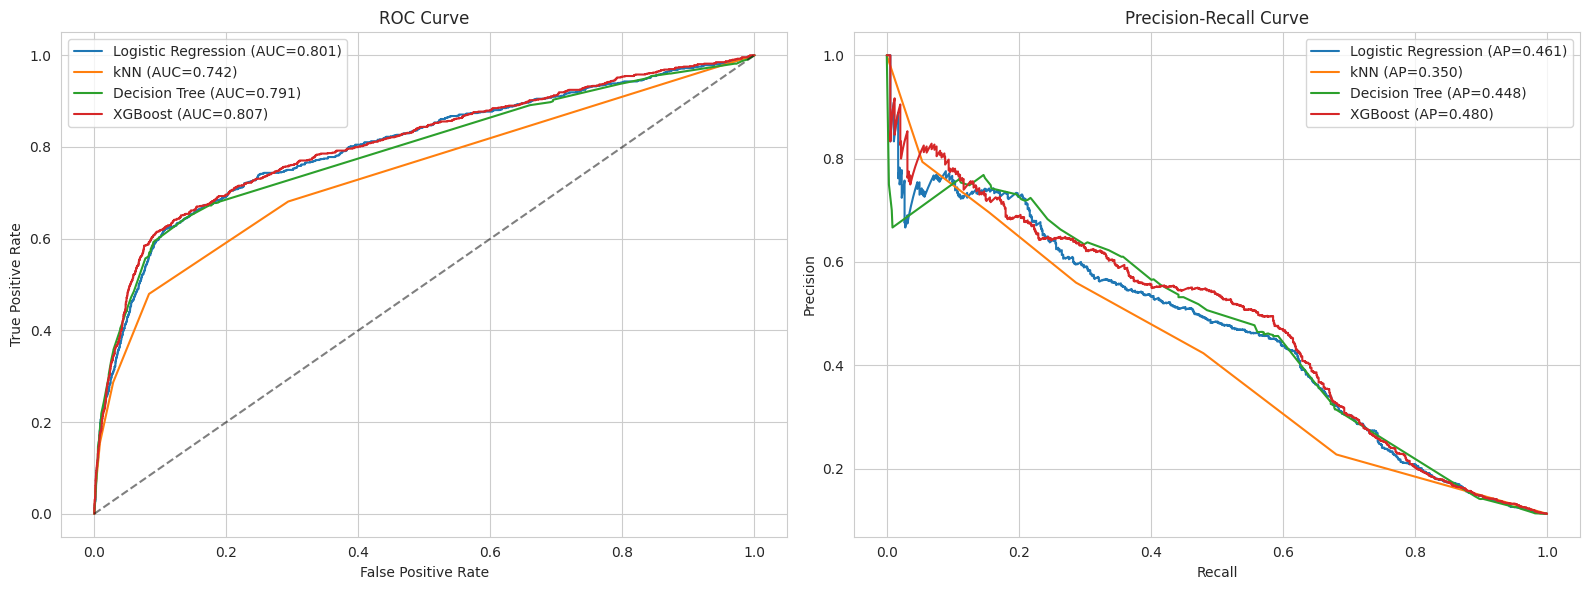

In [22]:
# ROC and Precision-Recall curves for all models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
for r in results:
    model = r['model']
    name = r['model_name']
    X_te = X_test_scaled if name in ['Logistic Regression', 'kNN'] else X_test

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        axes[0].plot(fpr, tpr, label=f'{name} (AUC={r["roc_auc_test"]:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True)

# Precision-Recall Curve
for r in results:
    model = r['model']
    name = r['model_name']
    X_te = X_test_scaled if name in ['Logistic Regression', 'kNN'] else X_test

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        ap = average_precision_score(y_test, y_proba)
        axes[1].plot(recall, precision, label=f'{name} (AP={ap:.3f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. XGBoost Hyperparameter Tuning

### 6.1 RandomizedSearchCV (sklearn)

In [23]:
# RandomizedSearchCV for XGBoost
from scipy.stats import randint, uniform

param_distributions = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0.5, 1.5),
}

xgb_rs = XGBClassifier(
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

random_search = RandomizedSearchCV(
    xgb_rs,
    param_distributions=param_distributions,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nBest parameters (RandomizedSearch):")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
print(f"\nBest F1 (CV): {random_search.best_score_:.4f}")

# Evaluate on test set
y_pred_rs = random_search.predict(X_test)
y_proba_rs = random_search.predict_proba(X_test)[:, 1]

f1_rs = f1_score(y_test, y_pred_rs)
roc_rs = roc_auc_score(y_test, y_proba_rs)
print(f"\nF1 (test): {f1_rs:.4f}")
print(f"ROC-AUC (test): {roc_rs:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rs))

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters (RandomizedSearch):
  colsample_bytree: 0.7368
  gamma: 0.0459
  learning_rate: 0.0382
  max_depth: 8
  min_child_weight: 4
  n_estimators: 303
  reg_alpha: 0.0172
  reg_lambda: 1.6450
  subsample: 0.9228

Best F1 (CV): 0.4708

F1 (test): 0.4972
ROC-AUC (test): 0.8058

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7310
           1       0.41      0.63      0.50       928

    accuracy                           0.86      8238
   macro avg       0.68      0.76      0.71      8238
weighted avg       0.89      0.86      0.87      8238



### 6.2 Hyperopt (Bayesian Optimization)

In [24]:
!pip install hyperopt -q

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# Hyperparameter search space
space = {
    'n_estimators': hp.choice('n_estimators', range(100, 500, 50)),
    'max_depth': hp.choice('max_depth', range(3, 10)),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'min_child_weight': hp.choice('min_child_weight', range(1, 10)),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0.5, 2.0),
}

def objective(params):
    model = XGBClassifier(
        **params,
        scale_pos_weight=scale_pos,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')

    return {'loss': -scores.mean(), 'status': STATUS_OK}

trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(42)
)

print("Best parameters (Hyperopt):")
print(best)

# Map parameters (hp.choice returns indices)
best_params_hyperopt = {
    'n_estimators': list(range(100, 500, 50))[best['n_estimators']],
    'max_depth': list(range(3, 10))[best['max_depth']],
    'learning_rate': best['learning_rate'],
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
    'min_child_weight': list(range(1, 10))[best['min_child_weight']],
    'gamma': best['gamma'],
    'reg_alpha': best['reg_alpha'],
    'reg_lambda': best['reg_lambda'],
}

print("\nDecoded parameters:")
for k, v in best_params_hyperopt.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

100%|██████████| 50/50 [09:42<00:00, 11.65s/trial, best loss: -0.4808798396873142]
Best parameters (Hyperopt):
{'colsample_bytree': np.float64(0.8195060969143677), 'gamma': np.float64(0.16782186834310986), 'learning_rate': np.float64(0.011105772597800339), 'max_depth': np.int64(5), 'min_child_weight': np.int64(0), 'n_estimators': np.int64(7), 'reg_alpha': np.float64(0.543585897692062), 'reg_lambda': np.float64(1.28294939010904), 'subsample': np.float64(0.8600667539194873)}

Decoded parameters:
  n_estimators: 450
  max_depth: 8
  learning_rate: 0.0111
  subsample: 0.8601
  colsample_bytree: 0.8195
  min_child_weight: 1
  gamma: 0.1678
  reg_alpha: 0.5436
  reg_lambda: 1.2829


In [25]:
# Train final model with Hyperopt parameters
xgb_hyperopt = XGBClassifier(
    **best_params_hyperopt,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_hyperopt.fit(X_train, y_train)

y_pred_ho = xgb_hyperopt.predict(X_test)
y_proba_ho = xgb_hyperopt.predict_proba(X_test)[:, 1]

f1_ho = f1_score(y_test, y_pred_ho)
roc_ho = roc_auc_score(y_test, y_proba_ho)

print(f"=== XGBoost (Hyperopt) ===")
print(f"F1 (test): {f1_ho:.4f}")
print(f"ROC-AUC (test): {roc_ho:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_ho))

# Compare tuning results
print("\n" + "="*60)
print("Tuning Comparison:")
print(f"  RandomizedSearch: F1={f1_rs:.4f}, ROC-AUC={roc_rs:.4f}")
print(f"  Hyperopt:         F1={f1_ho:.4f}, ROC-AUC={roc_ho:.4f}")
print(f"\nBoth tuning methods improved model quality compared to the baseline XGBoost.")
print(f"Hyperopt uses Bayesian Optimization, which can be more efficient with the same number of iterations.")

=== XGBoost (Hyperopt) ===
F1 (test): 0.5088
ROC-AUC (test): 0.8154

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7310
           1       0.42      0.64      0.51       928

    accuracy                           0.86      8238
   macro avg       0.69      0.76      0.71      8238
weighted avg       0.89      0.86      0.87      8238


Tuning Comparison:
  RandomizedSearch: F1=0.4972, ROC-AUC=0.8058
  Hyperopt:         F1=0.5088, ROC-AUC=0.8154

Both tuning methods improved model quality compared to the baseline XGBoost.
Hyperopt uses Bayesian Optimization, which can be more efficient with the same number of iterations.


## 7. Feature Importance

We use the best model (tuned XGBoost) to analyze feature importance.

Best model: XGBoost (Hyperopt)


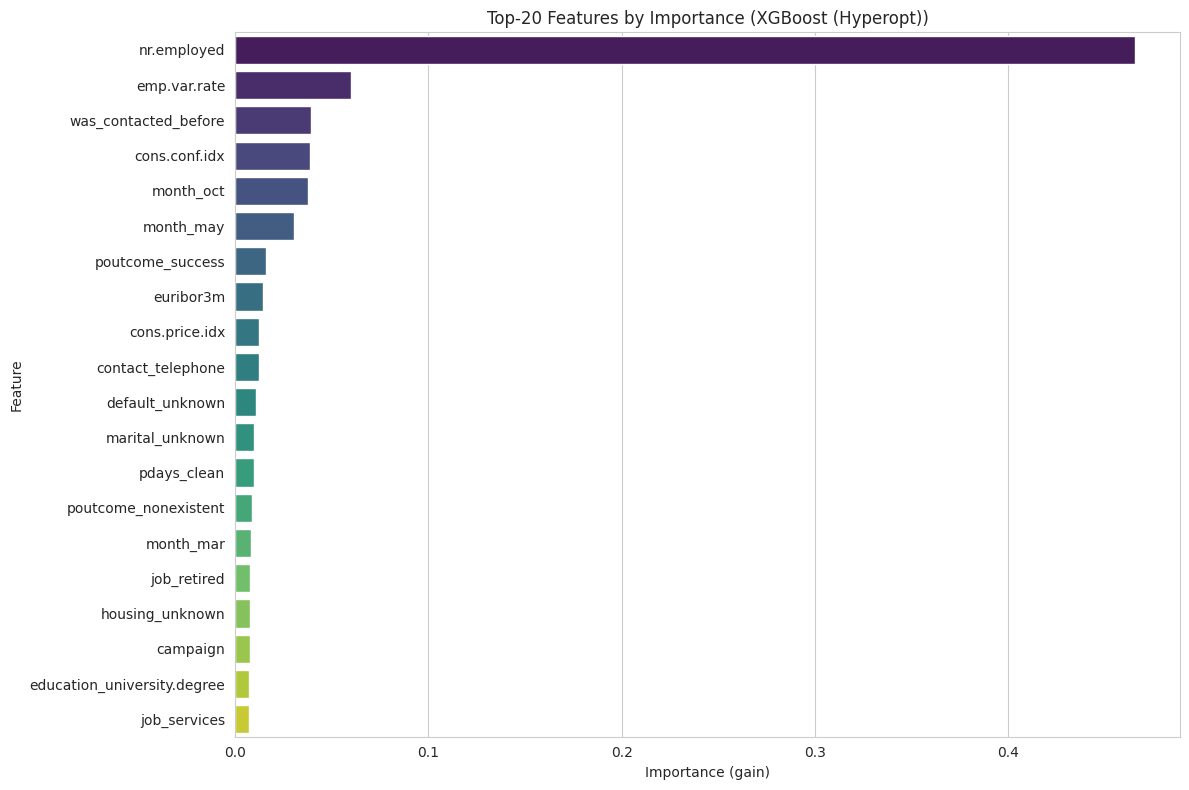


Top-10 most important features:
  nr.employed: 0.4655
  emp.var.rate: 0.0602
  was_contacted_before: 0.0390
  cons.conf.idx: 0.0386
  month_oct: 0.0376
  month_may: 0.0305
  poutcome_success: 0.0162
  euribor3m: 0.0144
  cons.price.idx: 0.0125
  contact_telephone: 0.0123


In [26]:
# Select the best model
if f1_ho >= f1_rs:
    best_model = xgb_hyperopt
    best_name = "XGBoost (Hyperopt)"
else:
    best_model = random_search.best_estimator_
    best_name = "XGBoost (RandomizedSearch)"

print(f"Best model: {best_name}")

# Feature importance (gain)
feature_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_imp.head(20), x='importance', y='feature', palette='viridis')
plt.title(f'Top-20 Features by Importance ({best_name})')
plt.xlabel('Importance (gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop-10 most important features:")
for i, row in feature_imp.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

### Feature Importance — Common Sense Analysis

The expected top features from a business perspective:

- **nr.employed, euribor3m, emp.var.rate** — macroeconomic indicators. This makes sense: deposit decisions strongly depend on the economic situation. When interest rates are low, deposits become more attractive as a safe investment.
- **poutcome_success** — if a client previously subscribed, they are likely to do so again. This aligns with standard customer behavior patterns.
- **age** — different age groups have varying propensity for deposits (retirees and students are more open).
- **contact_telephone** — the communication channel impacts conversion rates.
- **was_contacted_before** — prior contact indicates existing interest.
- **month** — campaign seasonality effects.

Overall, the feature importance ranking **is reasonable** from a business logic and common sense perspective. Macroeconomic factors indeed have a major impact on clients' financial decisions.

## 8. SHAP Analysis

We perform SHAP (SHapley Additive exPlanations) analysis to understand how each feature influences individual predictions.

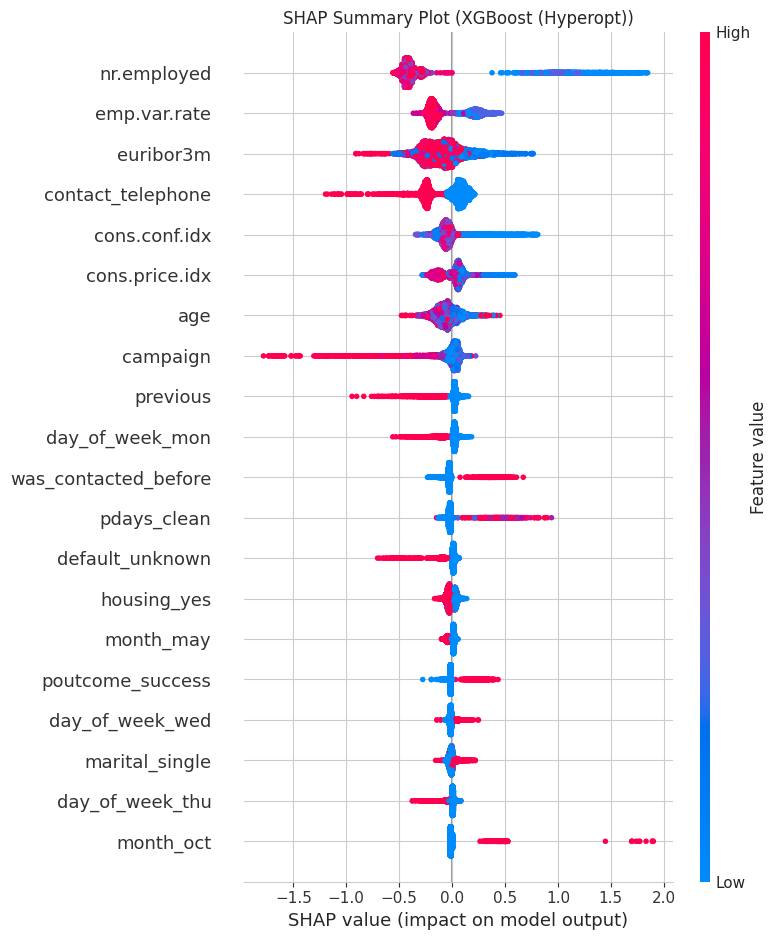

In [27]:
# SHAP analysis
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary plot (beeswarm)
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title(f'SHAP Summary Plot ({best_name})')
plt.tight_layout()
plt.show()

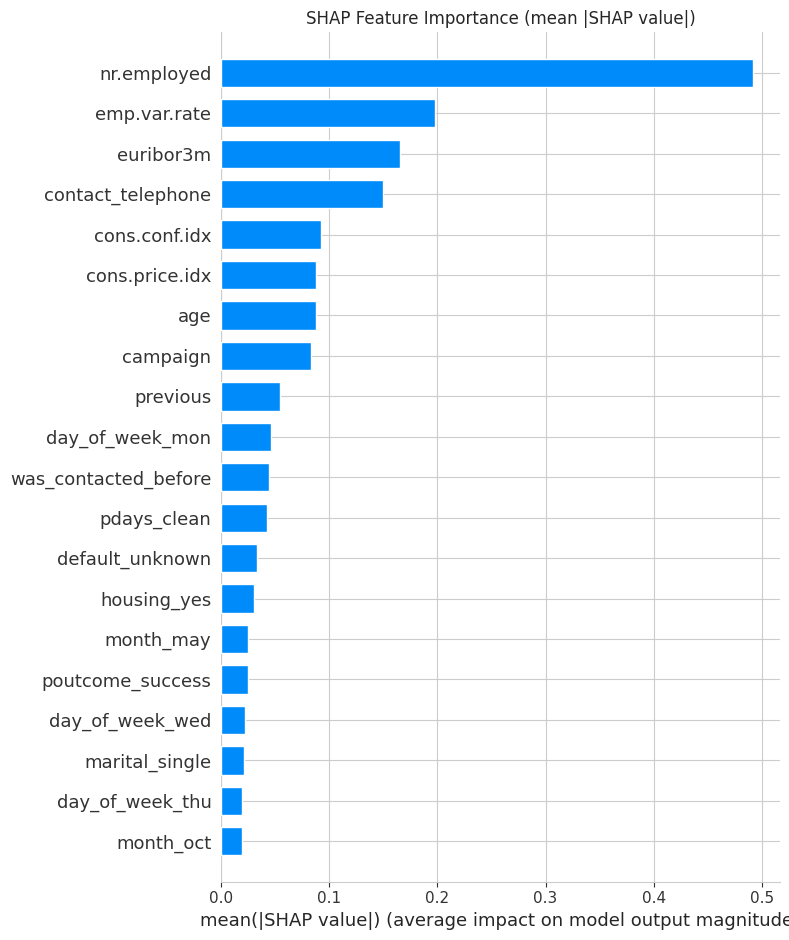

In [28]:
# SHAP bar plot — mean absolute contribution of each feature
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20, show=False)
plt.title(f'SHAP Feature Importance (mean |SHAP value|)')
plt.tight_layout()
plt.show()

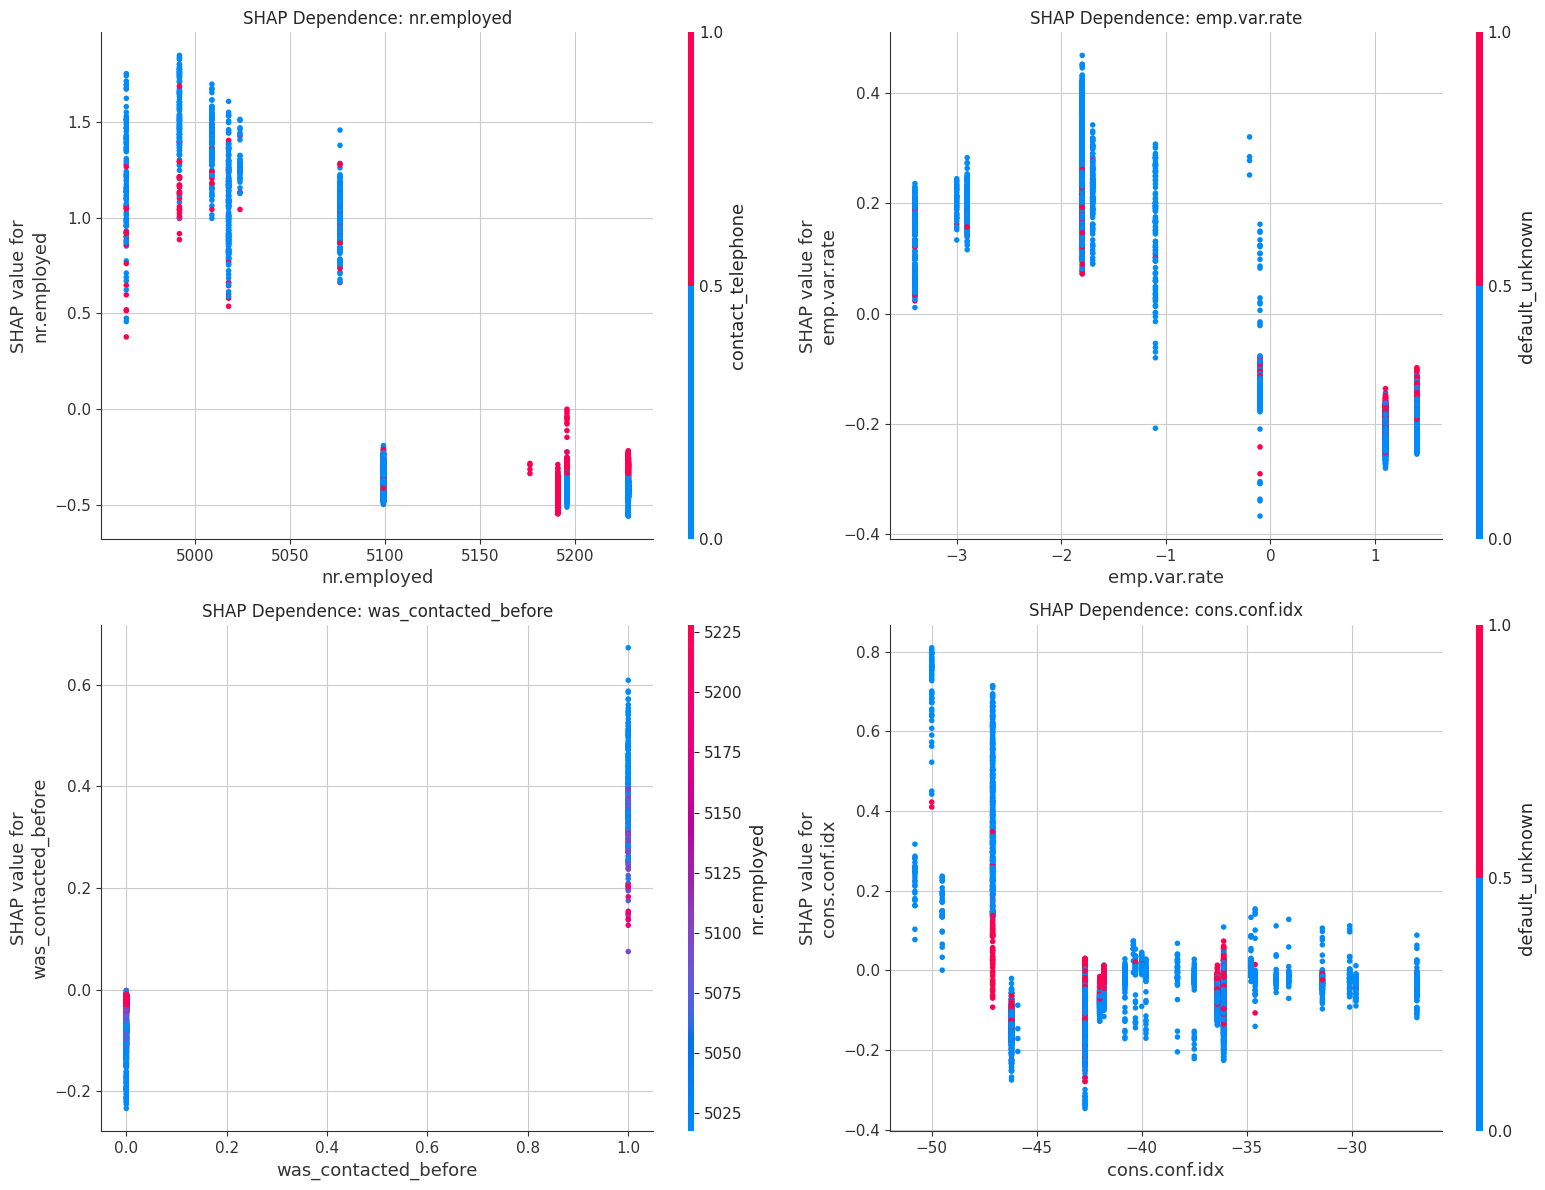

In [29]:
# SHAP dependence plots for the most important features
top_features = feature_imp.head(4)['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    shap.dependence_plot(feat, shap_values, X_test, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence: {feat}')

plt.tight_layout()
plt.show()

Example 1: Correctly classified as 'yes' (index 40138)


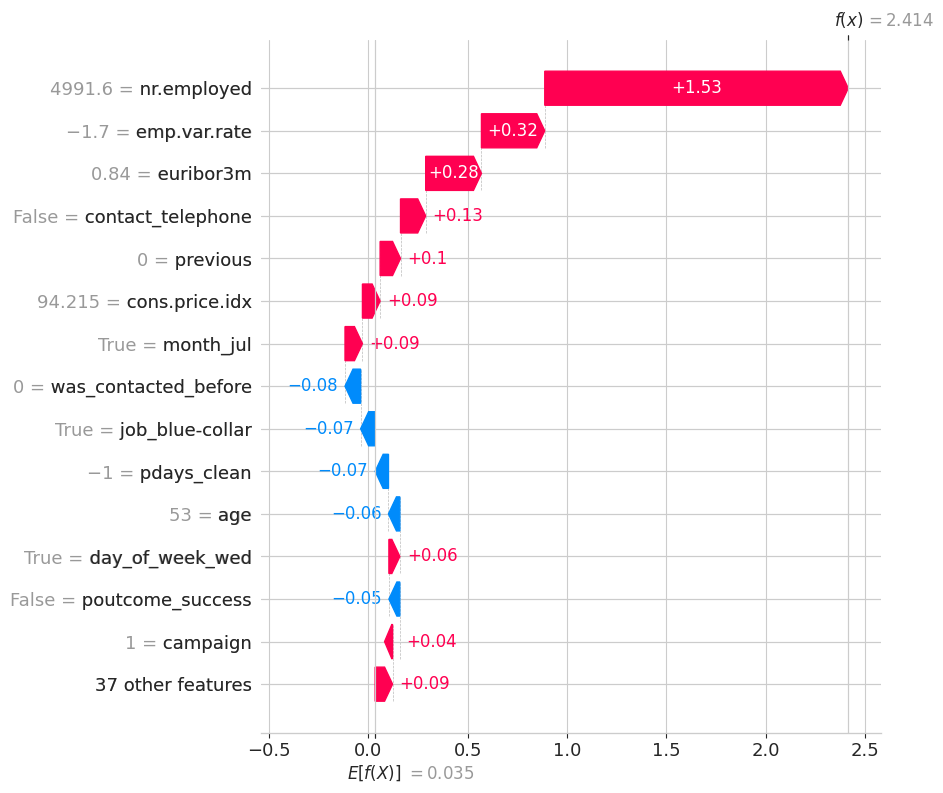


Example 2: Misclassified prediction (index 36380)
  True label: 0, Predicted: 1


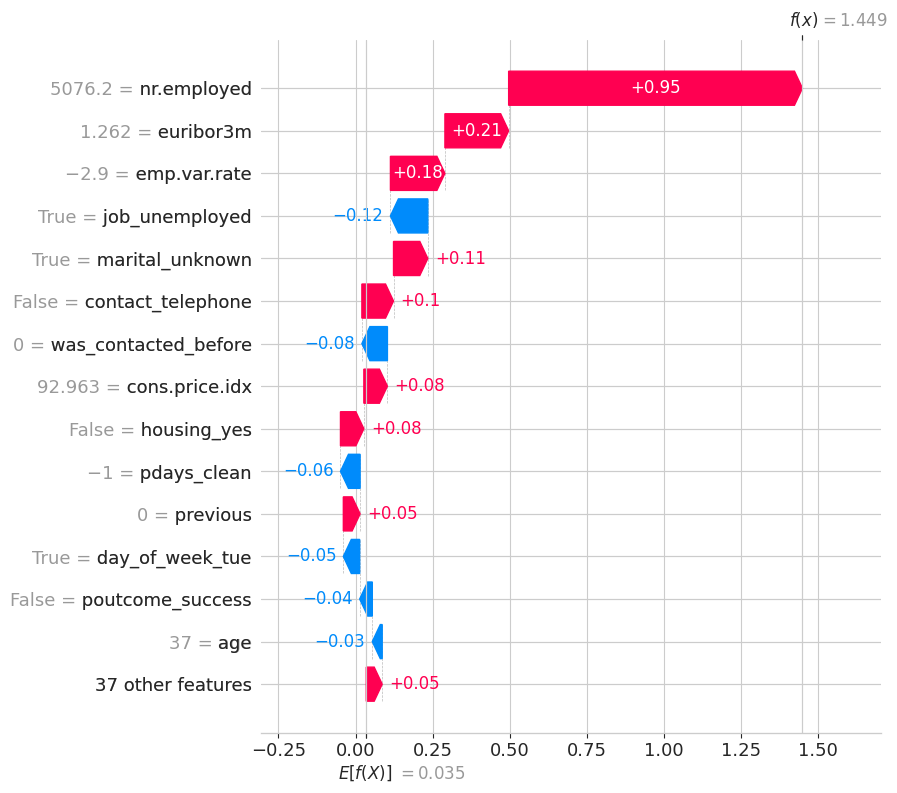

In [30]:
# SHAP waterfall plots for individual predictions
# Example 1: correctly classified as "yes", Example 2: misclassified

y_pred_best = best_model.predict(X_test)
correct_yes = X_test[(y_test == 1) & (y_pred_best == 1)].index
wrong_pred = X_test[(y_test != y_pred_best)].index

if len(correct_yes) > 0:
    idx = correct_yes[0]
    pos = list(X_test.index).index(idx)
    print(f"Example 1: Correctly classified as 'yes' (index {idx})")
    shap.waterfall_plot(shap.Explanation(values=shap_values[pos],
                                         base_values=explainer.expected_value,
                                         data=X_test.iloc[pos],
                                         feature_names=X_test.columns.tolist()),
                       max_display=15, show=True)

if len(wrong_pred) > 0:
    idx = wrong_pred[0]
    pos = list(X_test.index).index(idx)
    print(f"\nExample 2: Misclassified prediction (index {idx})")
    print(f"  True label: {y_test.loc[idx]}, Predicted: {y_pred_best[pos]}")
    shap.waterfall_plot(shap.Explanation(values=shap_values[pos],
                                         base_values=explainer.expected_value,
                                         data=X_test.iloc[pos],
                                         feature_names=X_test.columns.tolist()),
                       max_display=15, show=True)

## 9. Error Analysis

We analyze records where the model makes mistakes to understand how the solution can be improved.

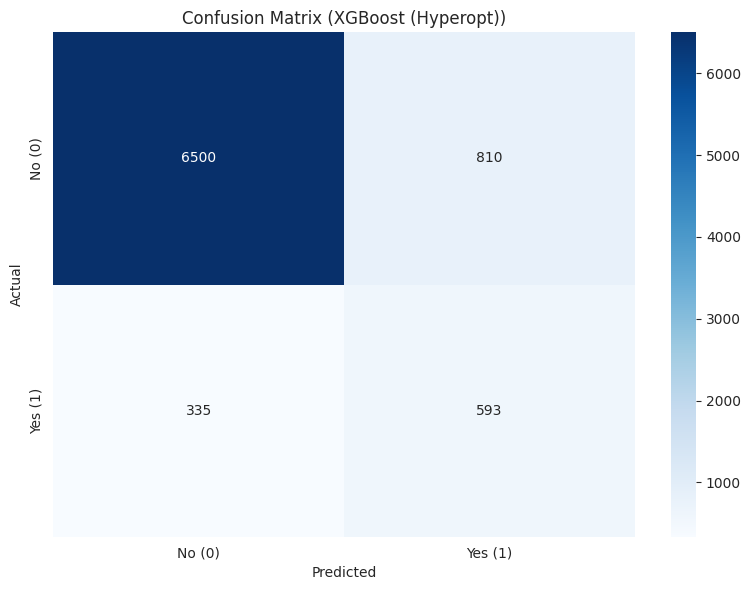

True Negatives: 6500 | False Positives: 810
False Negatives: 335 | True Positives: 593

False Positive Rate: 11.08% (falsely predicted as 'yes')
False Negative Rate: 36.10% (missed actual 'yes')


In [31]:
# Confusion Matrix
y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix ({best_name})')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn} | False Positives: {fp}")
print(f"False Negatives: {fn} | True Positives: {tp}")
print(f"\nFalse Positive Rate: {fp/(fp+tn):.2%} (falsely predicted as 'yes')")
print(f"False Negative Rate: {fn/(fn+tp):.2%} (missed actual 'yes')")

In [32]:
# Analyze misclassified records
errors_df = X_test.copy()
errors_df['y_true'] = y_test
errors_df['y_pred'] = y_pred_best
errors_df['y_proba'] = best_model.predict_proba(X_test)[:, 1]
errors_df['error_type'] = 'correct'
errors_df.loc[(errors_df['y_true'] == 0) & (errors_df['y_pred'] == 1), 'error_type'] = 'FP'
errors_df.loc[(errors_df['y_true'] == 1) & (errors_df['y_pred'] == 0), 'error_type'] = 'FN'

# Compare statistics: correct vs misclassified
print("=== Numeric Feature Comparison: FN (missed yes) vs Correctly Identified Yes ===\n")
correct_yes_df = errors_df[errors_df['error_type'] == 'correct'][errors_df['y_true'] == 1]
fn_df = errors_df[errors_df['error_type'] == 'FN']

comparison_cols = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
                   'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before', 'pdays_clean']

stats = pd.DataFrame({
    'Correct Yes (mean)': correct_yes_df[comparison_cols].mean(),
    'False Negatives (mean)': fn_df[comparison_cols].mean(),
    'Difference': fn_df[comparison_cols].mean() - correct_yes_df[comparison_cols].mean()
})
print(stats.round(3))

print(f"\n=== False Positives (false yes) ===")
fp_df = errors_df[errors_df['error_type'] == 'FP']
correct_no_df = errors_df[(errors_df['error_type'] == 'correct') & (errors_df['y_true'] == 0)]

stats_fp = pd.DataFrame({
    'Correct No (mean)': correct_no_df[comparison_cols].mean(),
    'False Positives (mean)': fp_df[comparison_cols].mean(),
    'Difference': fp_df[comparison_cols].mean() - correct_no_df[comparison_cols].mean()
})
print(stats_fp.round(3))

=== Numeric Feature Comparison: FN (missed yes) vs Correctly Identified Yes ===

                      Correct Yes (mean)  False Negatives (mean)  Difference
age                               42.238                  39.254      -2.984
campaign                           1.688                   2.651       0.963
previous                           0.680                   0.119      -0.560
emp.var.rate                      -2.216                   0.297       2.513
cons.price.idx                    93.182                  93.593       0.411
cons.conf.idx                    -38.822                 -41.502      -2.680
euribor3m                          1.060                   3.802       2.742
nr.employed                     5043.349                5179.126     135.777
was_contacted_before               0.309                   0.012      -0.297
pdays_clean                        1.037                  -0.890      -1.927

=== False Positives (false yes) ===
                      Correct No (m

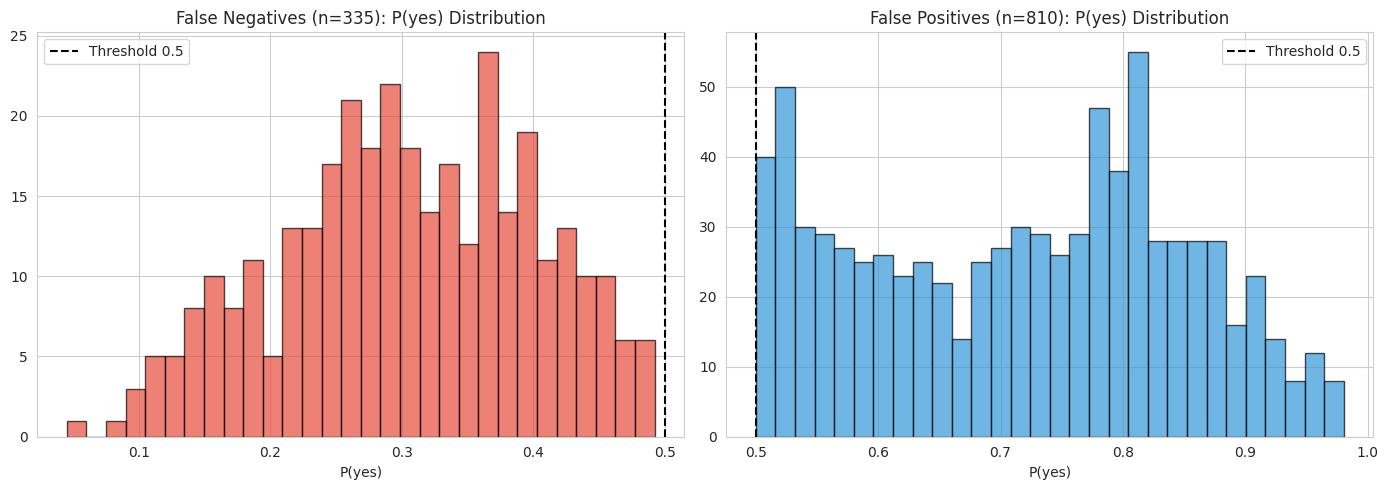

FN: mean probability = 0.304 (min: 0.045, max: 0.492)
FP: mean probability = 0.717 (min: 0.500, max: 0.980)

Many errors are near the 0.5 threshold — these are 'borderline' cases.


In [33]:
# Probability distribution for misclassified records
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FN: probability distribution
axes[0].hist(fn_df['y_proba'], bins=30, alpha=0.7, color='#e74c3c', edgecolor='black')
axes[0].axvline(x=0.5, color='black', linestyle='--', label='Threshold 0.5')
axes[0].set_title(f'False Negatives (n={len(fn_df)}): P(yes) Distribution')
axes[0].set_xlabel('P(yes)')
axes[0].legend()

# FP: probability distribution
axes[1].hist(fp_df['y_proba'], bins=30, alpha=0.7, color='#3498db', edgecolor='black')
axes[1].axvline(x=0.5, color='black', linestyle='--', label='Threshold 0.5')
axes[1].set_title(f'False Positives (n={len(fp_df)}): P(yes) Distribution')
axes[1].set_xlabel('P(yes)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"FN: mean probability = {fn_df['y_proba'].mean():.3f} (min: {fn_df['y_proba'].min():.3f}, max: {fn_df['y_proba'].max():.3f})")
print(f"FP: mean probability = {fp_df['y_proba'].mean():.3f} (min: {fp_df['y_proba'].min():.3f}, max: {fp_df['y_proba'].max():.3f})")
print(f"\nMany errors are near the 0.5 threshold — these are 'borderline' cases.")

## 10. Conclusions

### What Was Done

1. **EDA**: Conducted exploratory data analysis with visualizations. Identified strong class imbalance (~11% yes), formulated 7 hypotheses about feature influence on the target variable.

2. **Metric**: Selected F1-score as the primary metric (due to class imbalance), ROC-AUC as supplementary.

3. **Preprocessing**:
   - Removed `duration` (data leakage — not available before the call)
   - Grouped education levels (basic.4y/6y/9y → basic)
   - Created new features: `was_contacted_before`, `pdays_clean`
   - Capped outliers in `campaign` at the 99th percentile
   - One-Hot Encoding for categorical variables
   - StandardScaler for models requiring feature scaling

4. **Modeling**: Trained 4 models: Logistic Regression, kNN, Decision Tree, XGBoost.

5. **Tuning**: Performed XGBoost hyperparameter tuning using two methods — RandomizedSearchCV and Hyperopt (Bayesian Optimization).

6. **Interpretation**: Feature importance and SHAP analysis confirmed that macroeconomic indicators, previous campaign outcome, and age are the key factors.

7. **Error Analysis**: Most errors are borderline cases with probabilities near the 0.5 threshold.

### How to Improve the Solution

1. **Threshold optimization**: Find the optimal classification threshold instead of the default 0.5, based on business requirements (e.g., lower the threshold to avoid missing potential clients).

2. **Feature engineering**: Add new features — for example, interactions between age and job type, non-linear transformations of numeric features.

3. **Alternative models**: Try LightGBM, CatBoost, or model stacking for further quality improvement.

4. **Handle "unknown" values**: Instead of keeping "unknown" as a separate category, try imputing the most likely value.

5. **Cost-sensitive learning**: Adjust error weights according to the business cost of FP vs FN (cost of a wasted call vs a missed potential client).

6. **External data**: Enrich the model with external macroeconomic indicators or competitor data.